### 1. Импорты

In [35]:
import random
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import csv

### 2. Расчет движения машин

Запуск симуляции для очереди K = 0 (seed = 42)...


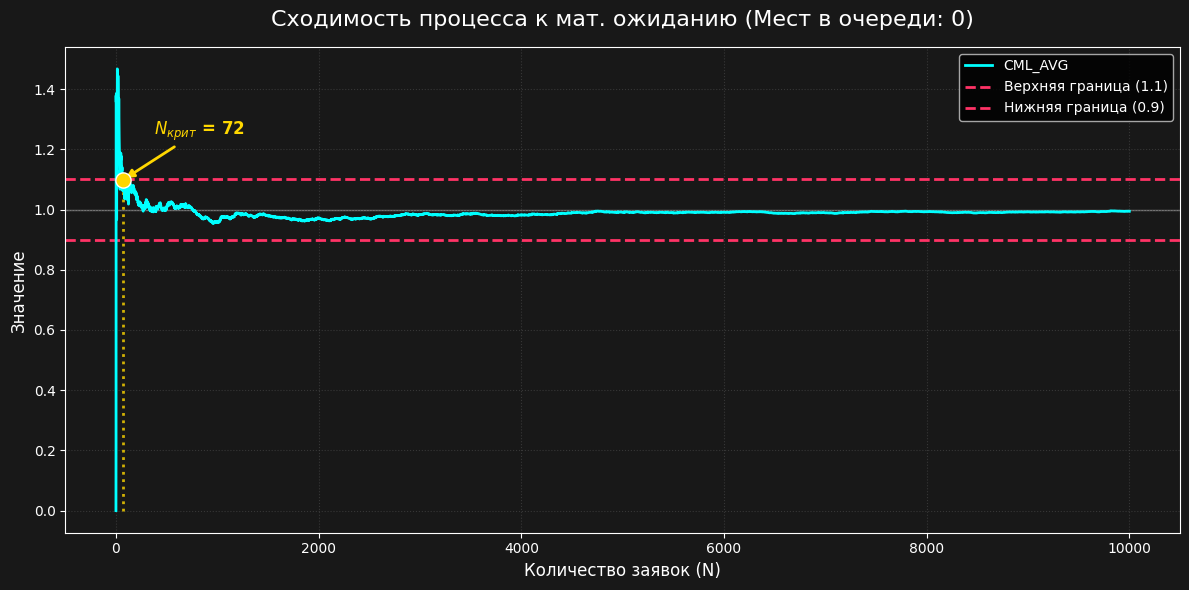

Запуск симуляции для очереди K = 1 (seed = 142)...


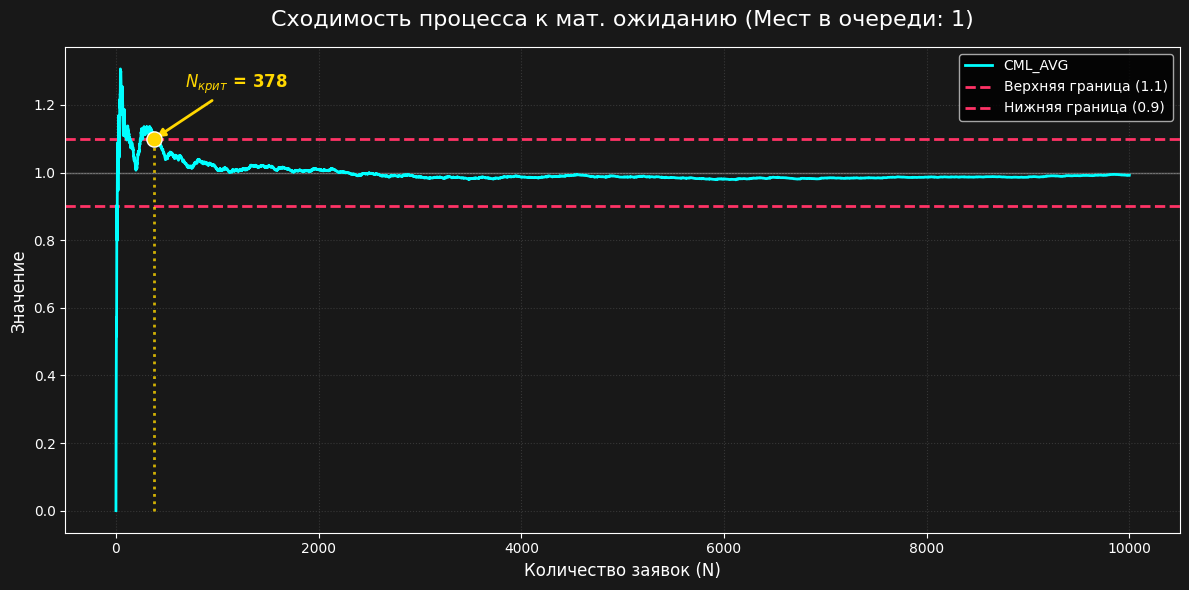

Запуск симуляции для очереди K = 2 (seed = 242)...


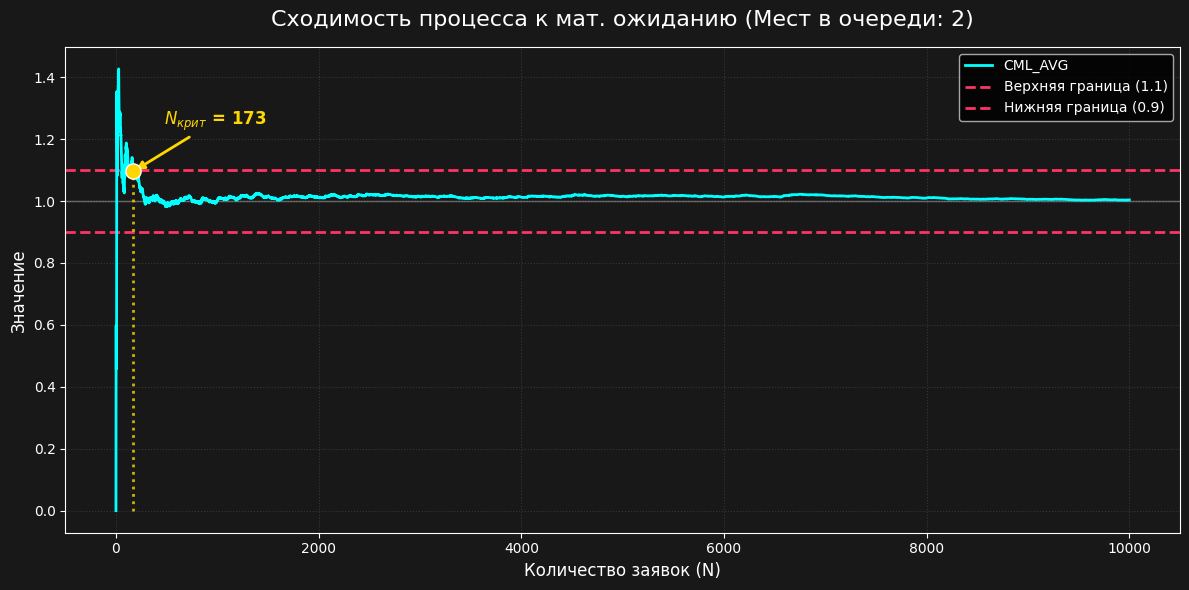

Запуск симуляции для очереди K = 3 (seed = 342)...


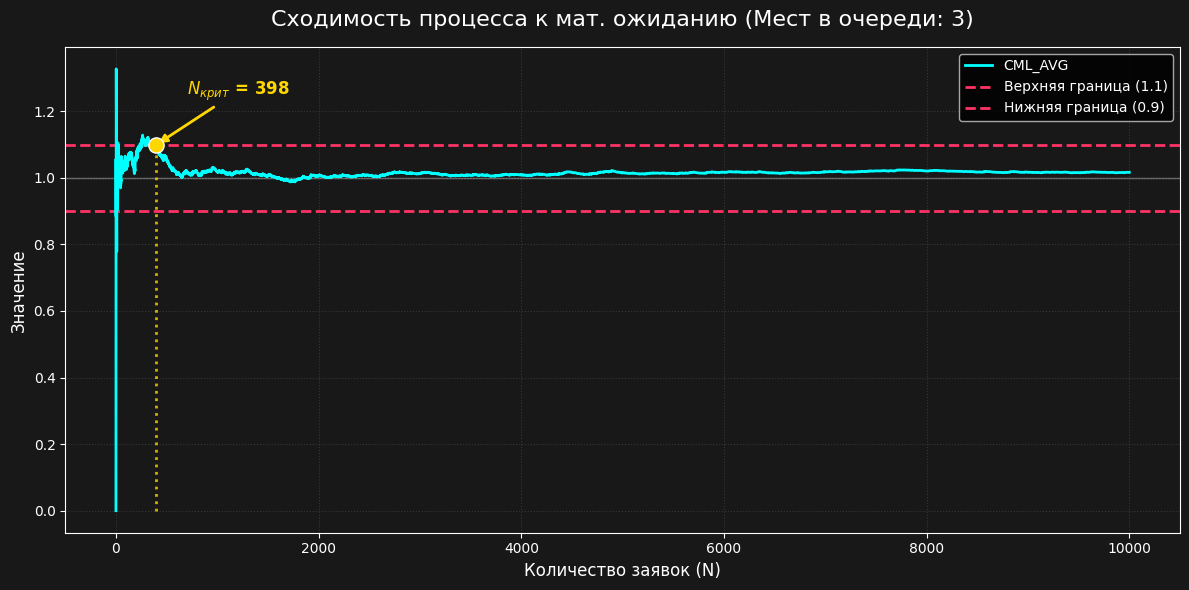

Запуск симуляции для очереди K = 4 (seed = 442)...


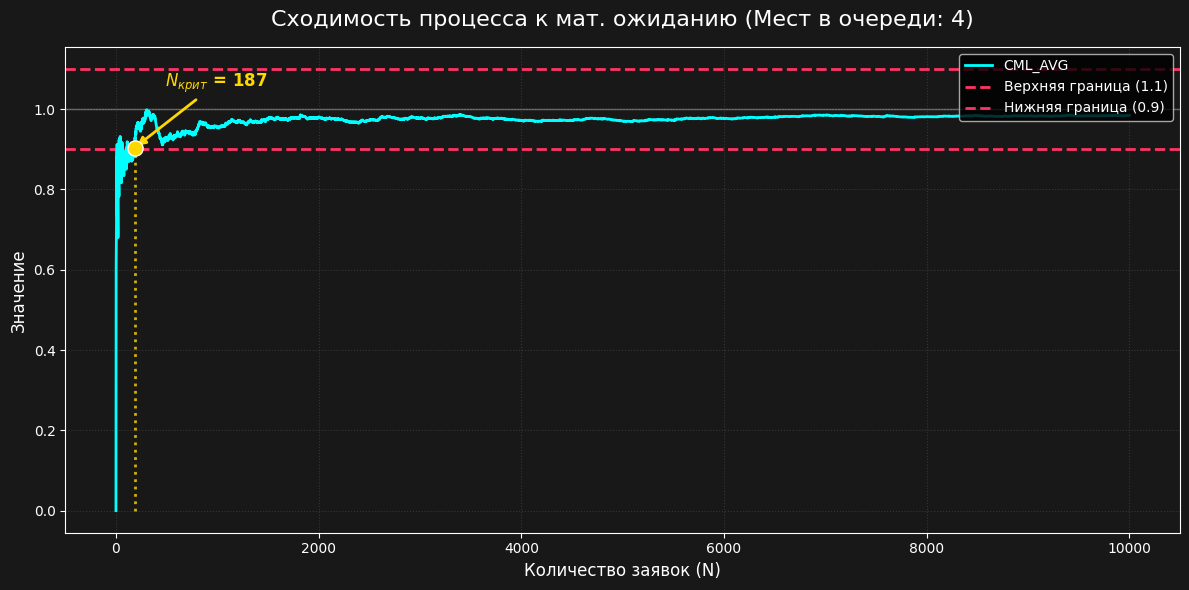

Запуск симуляции для очереди K = 5 (seed = 542)...


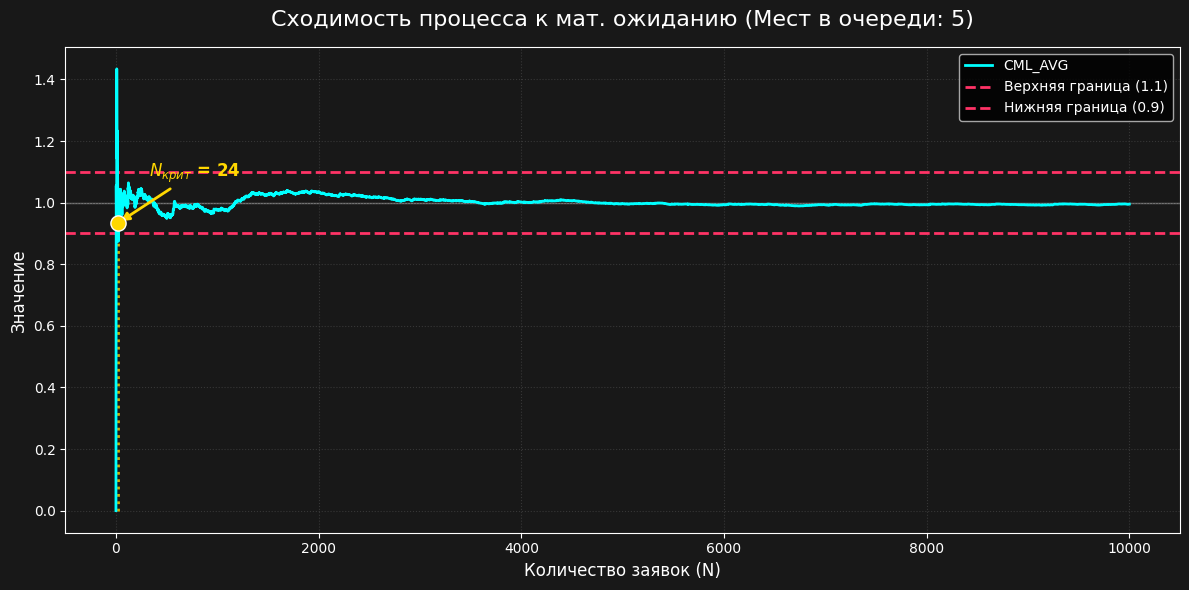

Запуск симуляции для очереди K = 6 (seed = 642)...


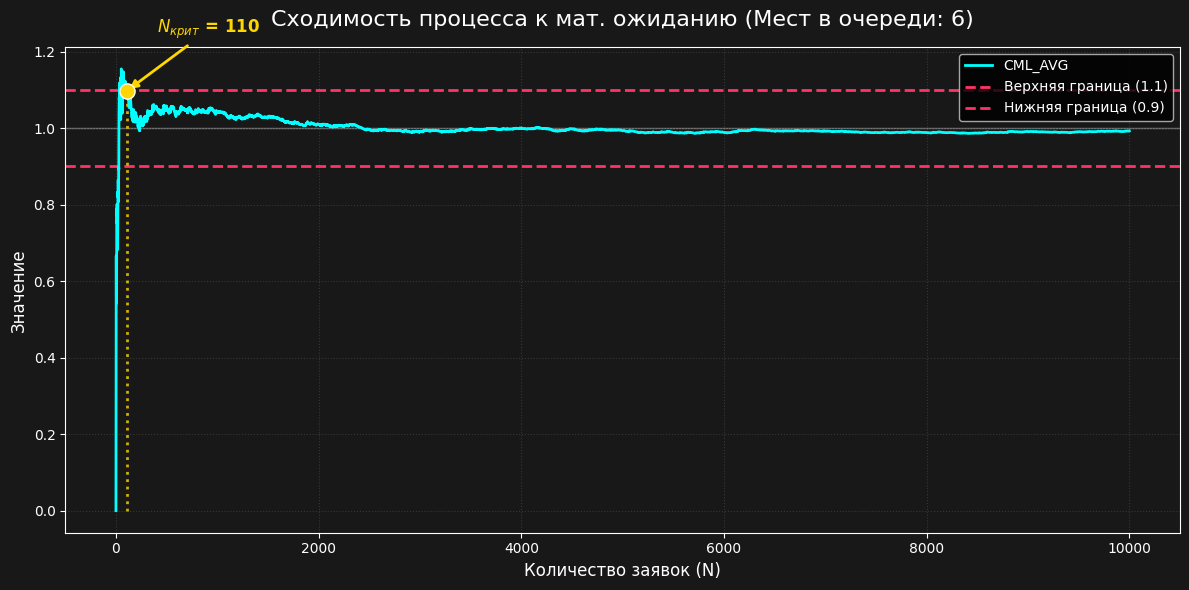


Все расчеты выполнены. Результаты сохранены в файл 'results_multiple_queues.csv'


In [48]:
class GasStationSim:
    def __init__(self, lambda_val, mu1, mu2, num_queues, seed):
        self.LAMBDA = lambda_val
        self.MU1 = mu1
        self.MU2 = mu2
        self.K = num_queues  # Количество мест в очереди

        # Массивы для логгирования
        self.CARS = []
        self.KO1 = []
        self.KO2 = []
        self.MO = [[] for _ in range(self.K)] # Динамический массив очередей: MO[0] - первое место, MO[K-1] - последнее
        self.SERVICE = []
        self.DOS = []
        self.CML_AVG = []

        self.START_PNT = None
        self.END_PNT = None
        self.N_crit = 0
        self.N2_crit = 0

        random.seed(seed) # Разные сиды для отсутствия корреляции

    def create_traffic_flow(self):
        """Создание массива прихода авто"""
        sum_tau = 0
        taus = []
        # Увеличили до 1000 заявок, чтобы точно хватило длины массива на 2*N_crit
        for _ in range(10000):
            r = random.random()
            tau = -1 * math.log(r) / self.LAMBDA
            sum_tau += tau
            self.CARS.append(sum_tau)
            taus.append(tau)
        self.CML_AVG = [self.LAMBDA * sum(taus[:i]) / (i + 1) for i in range(0, len(taus))]

    def service_on_ko1(self, start_serv):
        r = random.random()
        end_serv = start_serv - 1 * math.log(r) / self.MU1
        self.KO1.append((start_serv, end_serv))
        self.SERVICE.append(end_serv)

    def service_on_ko2(self, start_serv):
        r = random.random()
        end_serv = start_serv - 1 * math.log(r) / self.MU2
        self.KO2.append((start_serv, end_serv))
        self.SERVICE.append(end_serv)

    def create_service(self):
        """Обобщенная логика заполнения массивов обслуживания для любого числа очередей"""
        for car in self.CARS:
            # Если 1 колонка свободна
            if not self.KO1 or self.KO1[-1][1] <= car:
                self.service_on_ko1(car)
                continue
            # Если 2 колонка свободна
            if not self.KO2 or self.KO2[-1][1] <= car:
                self.service_on_ko2(car)
                continue

            # Проверяем очереди от первой к последней
            placed = False
            for q in range(self.K):
                # Если место в очереди q свободно
                if not self.MO[q] or self.MO[q][-1][1] <= car:
                    current_t = car
                    # Продвигаем машину по цепочке очередей от q-го места до колонки
                    for step in range(q, -1, -1):
                        if step == 0:
                            # Стоим на первом месте, ждем колонку
                            t_pump1 = self.KO1[-1][1]
                            t_pump2 = self.KO2[-1][1]
                            if t_pump2 < t_pump1:
                                self.MO[0].append((current_t, t_pump2))
                                self.service_on_ko2(t_pump2)
                            else:
                                self.MO[0].append((current_t, t_pump1))
                                self.service_on_ko1(t_pump1)
                        else:
                            # Машина ждет, пока впереди стоящая машина не уйдет вперед
                            leave_time = self.MO[step-1][-1][1]
                            self.MO[step].append((current_t, leave_time))
                            current_t = leave_time
                    placed = True
                    break

            # Если не нашлось ни одного свободного места
            if not placed:
                self.DOS.append(car)

    def calc_ncrit(self):
        n_crit_index = 0
        for i in range(len(self.CML_AVG) - 1, -1, -1):
            if not (0.9 <= self.CML_AVG[i] <= 1.1):
                n_crit_index = i + 1
                break
        self.N_crit = n_crit_index
        self.N2_crit = 2 * self.N_crit

        self.START_PNT = 1
 #       self.END_PNT = self.START_PNT + self.CARS[self.N2_crit - 1]
        self.END_PNT = self.START_PNT + 1000

    def gas_station_capacity(self):
        count = sum(1 for i in self.SERVICE if self.START_PNT <= i <= self.END_PNT)
        return count / (self.END_PNT - self.START_PNT)

    def probability_serv(self):
        count_serv = sum(1 for i in self.SERVICE if self.START_PNT <= i <= self.END_PNT)
        count_car = sum(1 for i in self.CARS if self.START_PNT <= i <= self.END_PNT)
        return count_serv / count_car

    def probability_dos(self):
        count_dos = sum(1 for i in self.DOS if self.START_PNT <= i <= self.END_PNT)
        count_car = sum(1 for i in self.CARS if self.START_PNT <= i <= self.END_PNT)
        return count_dos / count_car

    def probability_beasy_ko(self):
        all_intervals = self.KO1 + self.KO2
        events = []
        for start, end in all_intervals:
            if end <= self.START_PNT or start >= self.END_PNT:
                continue
            actual_start = max(start, self.START_PNT)
            actual_end = min(end, self.END_PNT)
            events.append((actual_start, 1))
            events.append((actual_end, -1))

        events.sort(key=lambda x: x[0])
        time_0 = time_1 = time_2 = 0
        current_busy = 0
        last_time = self.START_PNT

        for event_time, diff in events:
            delta = event_time - last_time
            if current_busy == 0: time_0 += delta
            elif current_busy == 1: time_1 += delta
            elif current_busy == 2: time_2 += delta
            current_busy += diff
            last_time = event_time

        if last_time < self.END_PNT:
            time_0 += (self.END_PNT - last_time)

        total_time = self.END_PNT - self.START_PNT
        return time_0 / total_time, time_1 / total_time, time_2 / total_time

    def probability_idle_ko(self):
        total_time = self.END_PNT - self.START_PNT
        time_beasy_ko1 = sum([min(end, self.END_PNT) - max(start, self.START_PNT) for start, end in self.KO1 if start < self.END_PNT and end > self.START_PNT])
        time_beasy_ko2 = sum([min(end, self.END_PNT) - max(start, self.START_PNT) for start, end in self.KO2 if start < self.END_PNT and end > self.START_PNT])
        return 1 - time_beasy_ko1 / total_time, 1 - time_beasy_ko2 / total_time

    def avg_cars_in_queue(self):
        total_time = self.END_PNT - self.START_PNT
        time_beasy_mo = 0
        for q in range(self.K):
            time_beasy_mo += sum([min(end, self.END_PNT) - max(start, self.START_PNT) for start, end in self.MO[q] if start < self.END_PNT and end > self.START_PNT])
        return time_beasy_mo / total_time

    def run(self):
        self.create_traffic_flow()
        self.create_service()
        self.calc_ncrit()

    def get_metrics(self):
        lambda_eff = self.gas_station_capacity()
        p_serv = self.probability_serv()
        p_dos = self.probability_dos()
        prob_0, prob_1, prob_2 = self.probability_beasy_ko()
        n_col_avg = prob_1 + 2 * prob_2
        n_q_avg = self.avg_cars_in_queue()
        p_idle_1, p_idle_2 = self.probability_idle_ko()
        t_wait = n_q_avg / lambda_eff if lambda_eff > 0 else 0
        t_serv = n_col_avg / lambda_eff if lambda_eff > 0 else 0

        return {
            'lambda_eff': lambda_eff,
            'p_service': p_serv,
            'p_reject': p_dos,
            'p_busy_ko1': prob_1,
            'p_busy_ko2': prob_2,
            'n_columns_avg': n_col_avg,
            'p_idle_ko1': p_idle_1,
            'p_idle_ko2': p_idle_2,
            'r_avg': n_q_avg,
            't_wait_avg': t_wait,
            't_service_avg': t_serv,
            't_system_avg': t_wait + t_serv,
            'n_avg': n_col_avg + n_q_avg
        }

    def plot_ncrit(self):
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(12, 6), facecolor='#181818')
        ax.set_facecolor('#181818')

        ax.plot(range(len(self.CML_AVG)), self.CML_AVG, color='#00FFFF', lw=2, label='CML_AVG', zorder=3)
        ax.axhline(1.1, color='#FF3366', linestyle='--', lw=2, label='Верхняя граница (1.1)', zorder=2)
        ax.axhline(0.9, color='#FF3366', linestyle='--', lw=2, label='Нижняя граница (0.9)', zorder=2)
        ax.axhline(1.0, color='white', linestyle='-', lw=1, alpha=0.4, zorder=1)

        ax.scatter(self.N_crit, self.CML_AVG[self.N_crit], color='#FFD700', s=120, zorder=5, edgecolors='white')
        ax.vlines(x=self.N_crit, ymin=min(self.CML_AVG), ymax=self.CML_AVG[self.N_crit], color='#FFD700', linestyle=':', lw=2, alpha=0.8)

        ax.annotate(f'$N_{{крит}}$ = {self.N_crit}',
                    xy=(self.N_crit, self.CML_AVG[self.N_crit]),
                    xytext=(self.N_crit + len(self.CML_AVG)*0.03, self.CML_AVG[self.N_crit] + 0.15),
                    arrowprops=dict(facecolor='#FFD700', edgecolor='#FFD700', arrowstyle='-|>', lw=2),
                    color='#FFD700', fontsize=12, fontweight='bold')

        ax.set_title(f'Сходимость процесса к мат. ожиданию (Мест в очереди: {self.K})', fontsize=16, color='white', pad=15)
        ax.set_xlabel('Количество заявок (N)', fontsize=12, color='white')
        ax.set_ylabel('Значение', fontsize=12, color='white')
        ax.grid(True, color='#444444', linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=10)

        plt.tight_layout()
        plt.show()

# --- ФУНКЦИЯ ГЕНЕРАЦИИ ДИНАМИЧЕСКОГО CSV ---

def generate_csv_for_queues(min_queue, max_queue, filename="results_multiple_queues.csv"):
    """
    Запускает симуляцию для диапазона очередей [min_queue; max_queue],
    строит графики Nкрит и сохраняет результаты в единый CSV файл.
    """
    results = {}

    # 1. Запуск симуляций
    for k in range(min_queue, max_queue + 1):
        # Генерируем уникальный seed для каждого размера очереди, чтобы избежать корреляции
        seed_val = 100 * k + 42
        print(f"Запуск симуляции для очереди K = {k} (seed = {seed_val})...")

        sim = GasStationSim(lambda_val=9, mu1=6, mu2=3, num_queues=k, seed=seed_val)
        sim.run()
        results[k] = sim.get_metrics()
        sim.plot_ncrit()  # Отрисовка графиков

    # 2. Формирование динамической структуры таблицы
    # Список кортежей: (Отображаемое имя, Ключ в словаре метрик, Единица измерения)
    metrics_info = [
        ('lambda_eff', 'lambda_eff', 'car/hour'),
        ('p_service', 'p_service', 'probability'),
        ('p_reject', 'p_reject', 'probability'),
        ('p_busy_ko1', 'p_busy_ko1', 'probability'),
        ('p_busy_ko2', 'p_busy_ko2', 'probability'),
        ('n_columns_avg', 'n_columns_avg', 'cars'),
        ('p_idle_ko1', 'p_idle_ko1', 'probability'),
        ('p_idle_ko2', 'p_idle_ko2', 'probability'),
        ('r_avg (queue length)', 'r_avg', 'cars'),
        ('t_wait_avg', 't_wait_avg', 'hour'),
        ('t_service_avg', 't_service_avg', 'hour'),
        ('t_system_avg', 't_system_avg', 'hour'),
        ('n_avg (total cars)', 'n_avg', 'cars')
    ]

    # Создаем заголовок CSV: ['Metric', 'K=3', 'K=4', ..., 'Unit']
    header_row = ['Metric'] + [f'K={k} (queues)' for k in range(min_queue, max_queue + 1)] + ['Unit']
    csv_rows = [header_row]

    # Заполняем строки
    for display_name, dict_key, unit in metrics_info:
        # Для текущей метрики собираем значения из всех симуляций [min_queue, max_queue]
        row_values = [results[k][dict_key] for k in range(min_queue, max_queue + 1)]
        row = [display_name] + row_values + [unit]
        csv_rows.append(row)

    # 3. Сохранение в CSV
    with open(filename, "w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerows(csv_rows)

    print(f"\nВсе расчеты выполнены. Результаты сохранены в файл '{filename}'")

# --- ЗАПУСК ---
generate_csv_for_queues(0, 6)